In [49]:
import sympy as sp
import numpy as np
import control as ct
import matplotlib.pyplot as plt

In [50]:
# symbolic state and input
H, L, u = sp.symbols('H L u')
a_s, b_s, c_s, d_s, k_s, r_s = sp.symbols('a b c d k r')

# Eq. 5 and Eq. 2 (u only enters the hare equation)
dHdt = (r_s + u)*H*(1 - H/k_s) - (a_s*H*L)/(c_s + H)
dLdt = b_s*(a_s*H*L)/(c_s + H) - d_s*L

f = sp.Matrix([dHdt, dLdt])
x = sp.Matrix([H, L])

# output: y = L  (Eq. paper defines w = L, i.e. h(x,u) = L)
h = sp.Matrix([L])

A_sym = f.jacobian(x)          # ∂f/∂x
B_sym = f.jacobian([u])        # ∂f/∂u
C_sym = h.jacobian(x)          # ∂h/∂x
D_sym = h.jacobian([u])        # ∂h/∂u

#print("A =")
#sp.pprint(A_sym)
#print("B =")
#sp.pprint(B_sym)

a, b, c, d, k, r = 3.2, 0.6, 50, 0.56, 125, 1.6

He = c*d / (a*b - d)
Le = b*c*r*(a*b*k - c*d - d*k) / ((a*b - d)**2 * k)

subs_dict = {
    a_s: a, b_s: b, c_s: c, d_s: d, k_s: k, r_s: r,
    H: He, L: Le, u: 0     # u_e = 0, no food modulation at equilibrium
}

A =
 [[ 0.12627451 -0.93333333]
 [ 0.568       0.        ]]
B =
 [[17.19723183]
 [ 0.        ]]
C =
 [[0. 1.]]
D =
 [[0.]]


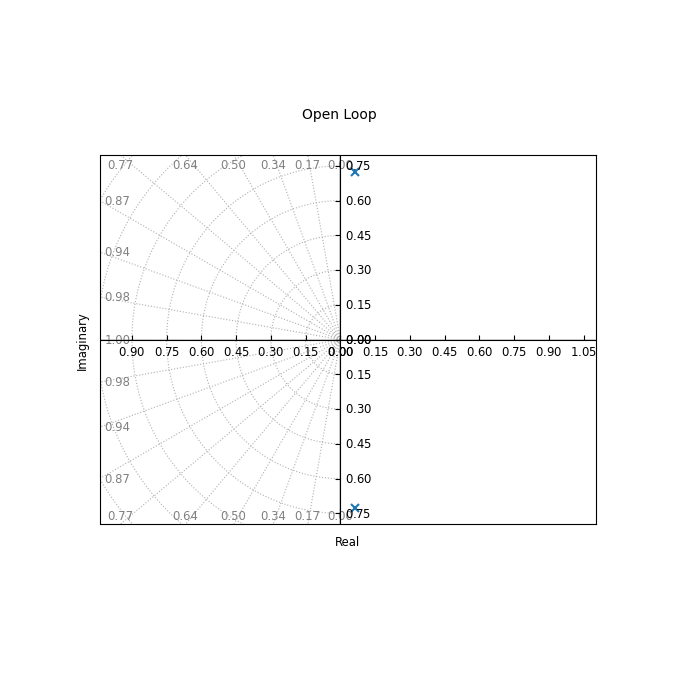

In [51]:
A_num = np.array(A_sym.subs(subs_dict)).astype(float)
B_num = np.array(B_sym.subs(subs_dict)).astype(float)
C_num = np.array(C_sym.subs(subs_dict)).astype(float)
D_num = np.array(D_sym.subs(subs_dict)).astype(float)

print("A =\n", A_num)
print("B =\n", B_num)
print("C =\n", C_num)
print("D =\n", D_num)

eigvals, eigvecs = np.linalg.eig(A_num)

sys_ss = ct.ss(A_num, B_num, C_num, D_num)
sys_tf = ct.ss2tf(sys_ss)

#Pole Zero Map
ct.pzmap(sys_ss, title='Open Loop', grid=True)
plt.show()


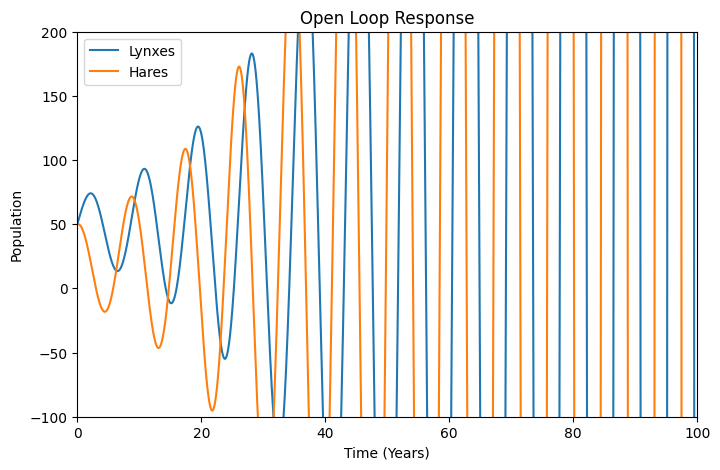

In [52]:
#Graphing the open loop response
H0 = 50
L0 = 50
z0 = np.array([H0 - He, L0 - Le])

t = np.arange(0, 100 + 0.01, 0.01)
ustep = np.ones_like(t)

sys_ss_H = ct.ss(A_num, B_num,[[1.0, 0.0]], D_num)

resp_L = ct.forced_response(sys_ss,   T=t, U=ustep, X0=z0)
resp_H = ct.forced_response(sys_ss_H,   T=t, U=ustep, X0=z0)

Lout = resp_L.outputs + Le
Hout = resp_H.outputs + He
Time = resp_L.time

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Time, Lout, label='Lynxes')
ax.plot(Time, Hout, label='Hares')
ax.set_xlabel('Time (Years)')
ax.set_ylabel('Population')
ax.legend()
ax.set_title('Open Loop Response')
ax.axis([0, 100, -100, 200]) 
plt.show()

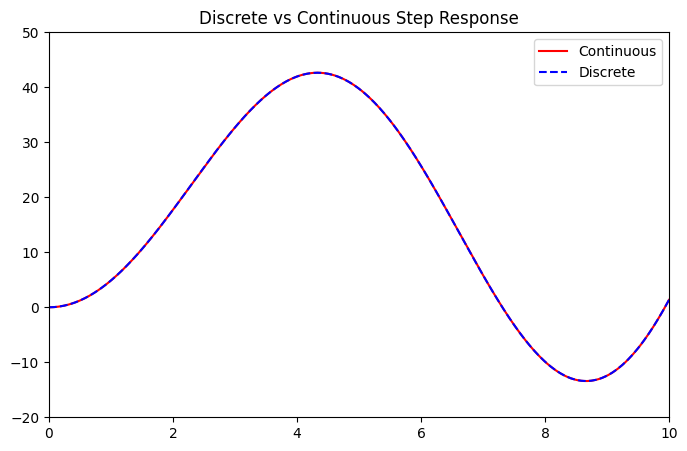

In [53]:
#Lyapunov analysis
P = ct.lyap(A_num, np.eye(2))
lyapvals, lyapvecs = np.linalg.eig(P)

#Plotting the discrete step response of the system
dt = 1/12
sys_ss_d = ct.c2d(sys_ss, dt)

t_cont = np.linspace(0, 10, 1000)
t_disc = np.arange(0, 10 + dt, dt)

resp_cont = ct.step_response(sys_ss, T=t_cont)
resp_disc = ct.step_response(sys_ss_d, T=t_disc)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(resp_cont.time, resp_cont.outputs, color='red', label='Continuous')
ax.plot(resp_disc.time, resp_disc.outputs, '--', color='blue', label='Discrete')
ax.axis([0, 10, -20, 50])
ax.legend()
ax.title.set_text('Discrete vs Continuous Step Response')
plt.show()

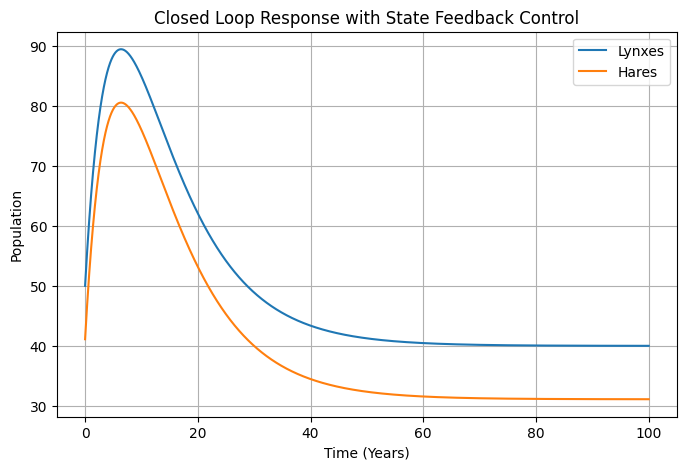

In [54]:
#Introducing State Feedback Control

Ld = 40 # Desired Lynx Population
Co = ct.ctrb(A_num, B_num)
rank = np.linalg.matrix_rank(Co)

# Calculating gain matriix and feedforward gain
Q = C_num.T @ C_num
Q[0,0] = 1.5
R = np.array([[1.0]])

#K, S, E = ct.lqr(A_num, B_num, Q, R) # LQR Pole Placement
K = ct.place(A_num, B_num, [-0.1, -0.2]) #Deliberate Pole Placement

kf = -1 / (C_num @ np.linalg.inv(A_num - B_num @ K) @ B_num)

Ac = A_num - B_num @ K
Bc = B_num * kf * (Ld - Le)
Cc = C_num
Dc = D_num

closed_ss = ct.ss(Ac, Bc, Cc, Dc)
closed_ss_H = ct.ss(Ac, Bc, [[1.0, 0]], Dc)

Z2 = ct.forced_response(closed_ss, T=t, U=ustep, X0=z0)
Z1 = ct.forced_response(closed_ss_H, T=t, U=ustep, X0=z0)

Lc = Z2.outputs + Le
Hc = Z2.outputs + He
tc = Z2.time

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tc, Lc, label='Lynxes')
ax.plot(tc, Hc, label='Hares')
ax.set_xlabel('Time (Years)')
ax.set_ylabel('Population')
ax.legend()
ax.set_title('Closed Loop Response with State Feedback Control')
#ax.axis([0, 20, 30, 65])
ax.grid()


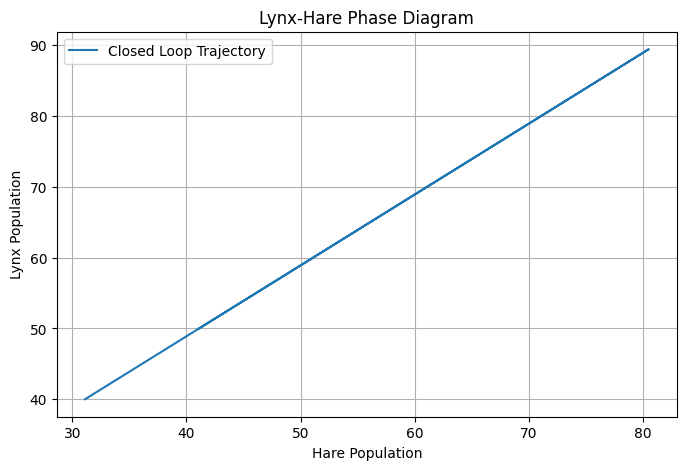

In [55]:
# Lynx Hare Phase Diagram

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Hc, Lc, label='Closed Loop Trajectory')
ax.set_xlabel('Hare Population')
ax.set_ylabel('Lynx Population')
ax.legend()
ax.set_title('Lynx-Hare Phase Diagram')
ax.grid()